In [1]:
import numpy as np 
import pandas as pd 
import os

# Data Collection & Understanding

In [2]:
data_supply = pd.read_csv('d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/raw/DataCoSupplyChainDataset.csv', encoding = "latin1")
data_supply.head

<bound method NDFrame.head of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per customer

In [3]:
data_supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

# EDA

## Overview

In [4]:
data_supply.shape

(180519, 53)

In [5]:
data_supply.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [6]:
data_supply.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [7]:
data_supply = data_supply.drop(
    columns=['Product Description', 'Order Zipcode']
)

In [8]:
missing = data_supply.isnull().sum()
missing_percent = (missing / len(data_supply)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
})

missing_table.sort_values('Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662
Days for shipping (real),0,0.000000
Days for shipment (scheduled),0,0.000000
Benefit per order,0,0.000000
Delivery Status,0,0.000000
Sales per customer,0,0.000000
Category Id,0,0.000000
Category Name,0,0.000000
Customer City,0,0.000000


In [9]:
data_supply.dropna()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


## Distribusi & Correlation Data

<Axes: >

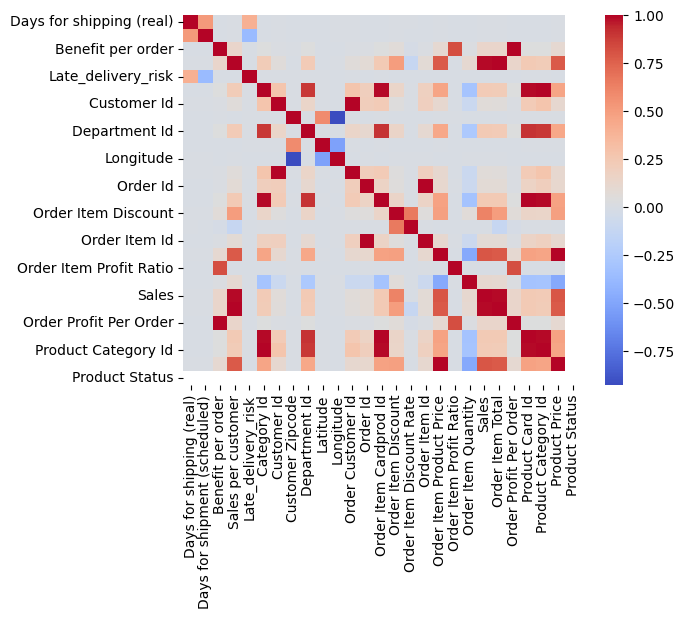

In [10]:
import seaborn as sns

corr = data_supply.select_dtypes(include='number').corr()

sns.heatmap(corr, cmap='coolwarm')

<Axes: xlabel='Sales', ylabel='Count'>

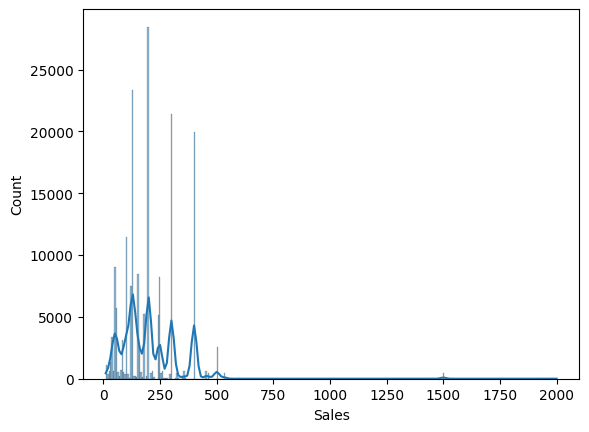

In [11]:
sns.histplot(data_supply['Sales'], kde=True)

In [12]:
## Boxplot dataset supply

## Shipping Performance

In [13]:
data_supply['Shipping_Delay'] = (
    data_supply['Days for shipping (real)']
    - data_supply['Days for shipment (scheduled)']
)

<Axes: xlabel='Shipping_Delay', ylabel='Count'>

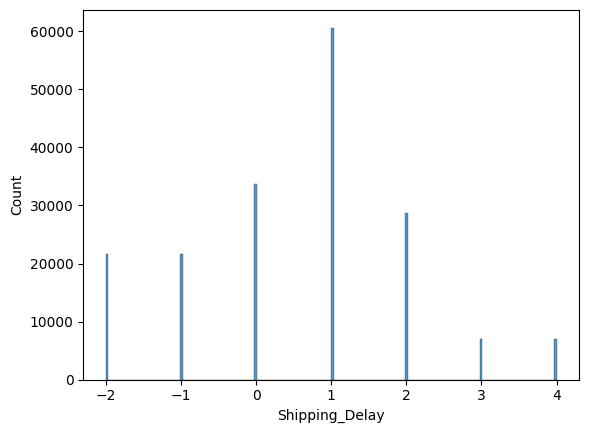

In [14]:
sns.histplot(data_supply['Shipping_Delay'])

## Late Delivery Risk Analysis

<Axes: xlabel='Late_delivery_risk', ylabel='count'>

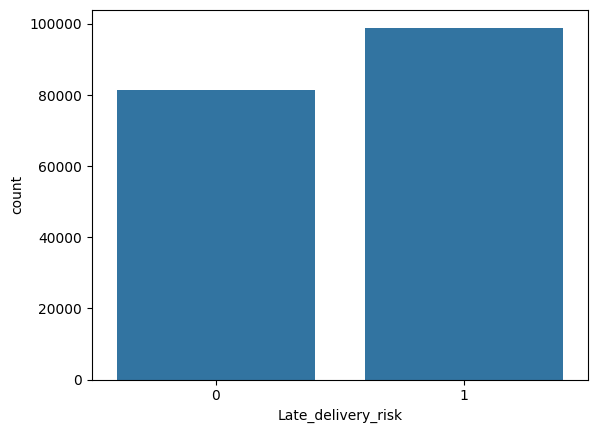

In [15]:
sns.countplot(x='Late_delivery_risk', data=data_supply)

<Axes: xlabel='Late_delivery_risk', ylabel='Days for shipping (real)'>

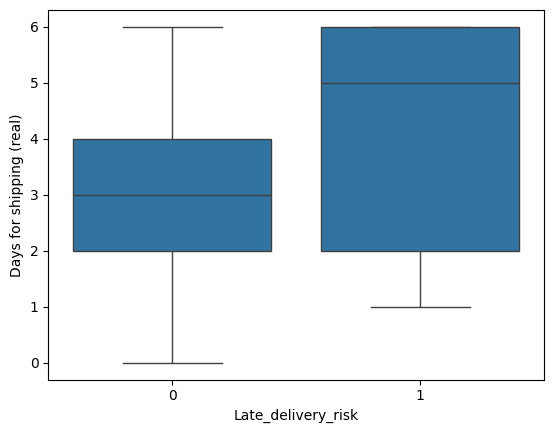

In [16]:
sns.boxplot(x='Late_delivery_risk',
            y='Days for shipping (real)',
            data=data_supply)

<Axes: xlabel='Late_delivery_risk', ylabel='Shipping_Delay'>

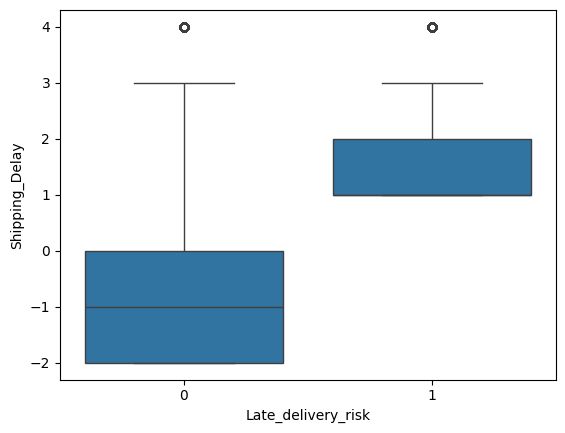

In [17]:
sns.boxplot(
    x='Late_delivery_risk',
    y='Shipping_Delay',
    data=data_supply
)

<Axes: xlabel='Shipping Mode', ylabel='Shipping_Delay'>

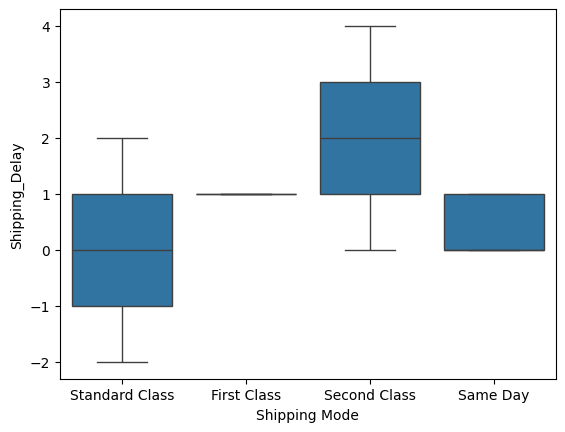

In [18]:
sns.boxplot(
    x='Shipping Mode',
    y='Shipping_Delay',
    data=data_supply
)

<Axes: xlabel='Market', ylabel='count'>

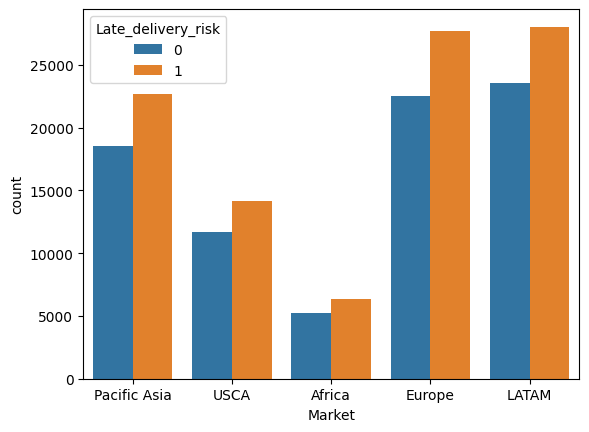

In [19]:
sns.countplot(
    data=data_supply,
    x='Market',
    hue='Late_delivery_risk'
)

## Pricing Analysis

<Axes: ylabel='Order Item Product Price'>

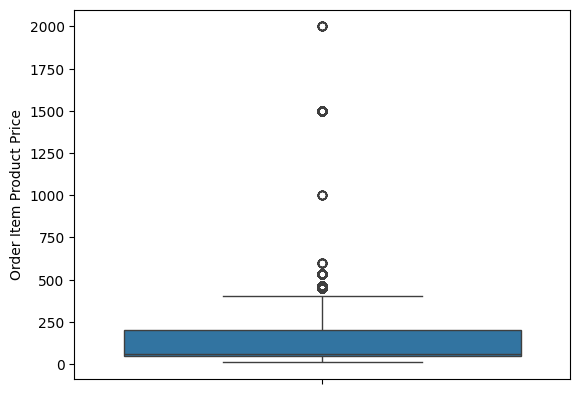

In [20]:
sns.boxplot(y=data_supply['Order Item Product Price'])

In [21]:
data_supply['Price_Ratio'] = (
    data_supply['Order Item Product Price']
    / data_supply['Product Price'])

## Profit Analysis

<Axes: xlabel='Order Profit Per Order', ylabel='Count'>

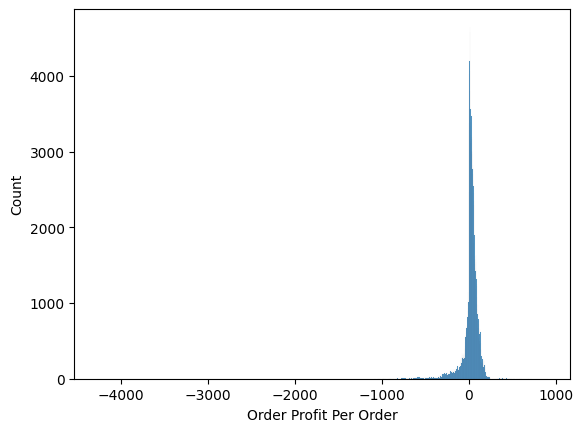

In [22]:
sns.histplot(data_supply['Order Profit Per Order'])

## Fraudiness

<Axes: ylabel='Order Item Product Price'>

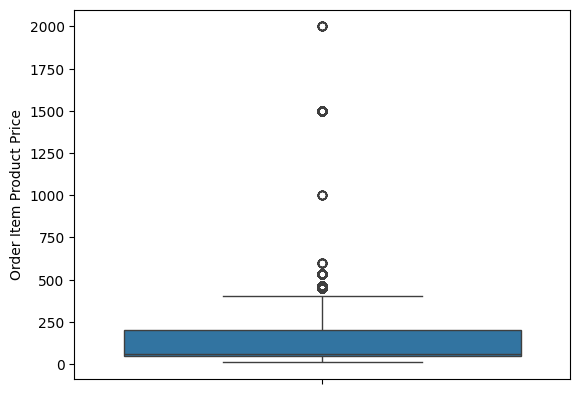

In [23]:
sns.boxplot(y=data_supply['Order Item Product Price'])

<Axes: xlabel='Price_Ratio', ylabel='Count'>

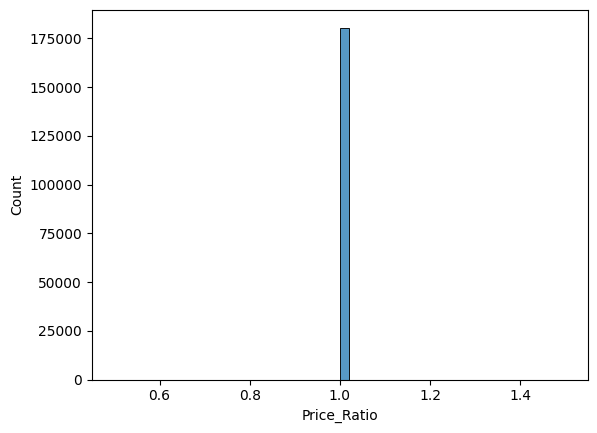

In [24]:
sns.histplot(data_supply['Price_Ratio'], bins=50)

<Axes: ylabel='Order Profit Per Order'>

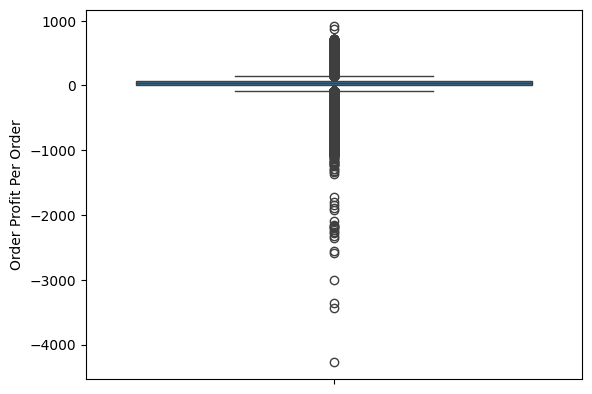

In [25]:
sns.boxplot(y=data_supply['Order Profit Per Order'])

<Axes: xlabel='Order Item Discount Rate', ylabel='Count'>

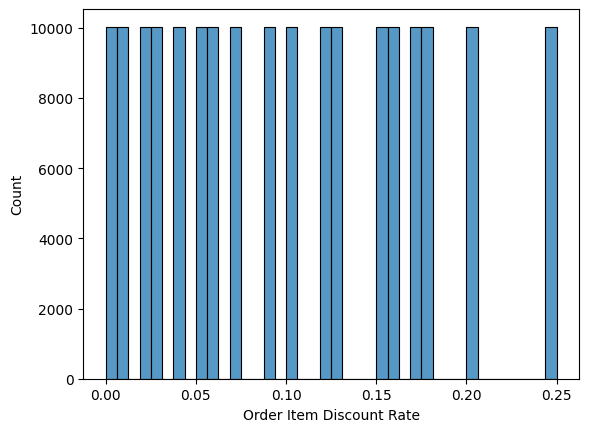

In [26]:
# Discount Analysis

sns.histplot(
    data_supply['Order Item Discount Rate'],
    bins=40
)

## Inventory Manipulation

<Axes: ylabel='Order Item Quantity'>

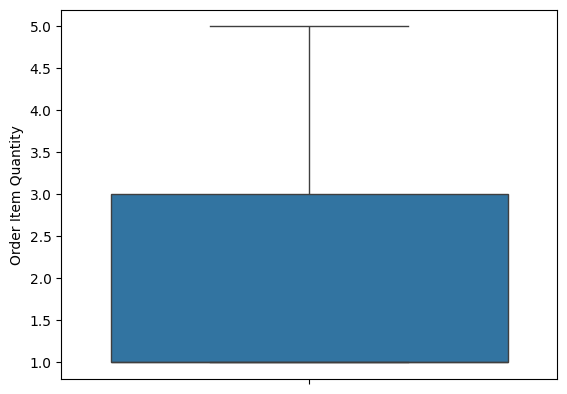

In [27]:
# Quantity Distribution

sns.boxplot(y=data_supply['Order Item Quantity'])

<Axes: xlabel='Order Item Quantity', ylabel='Sales'>

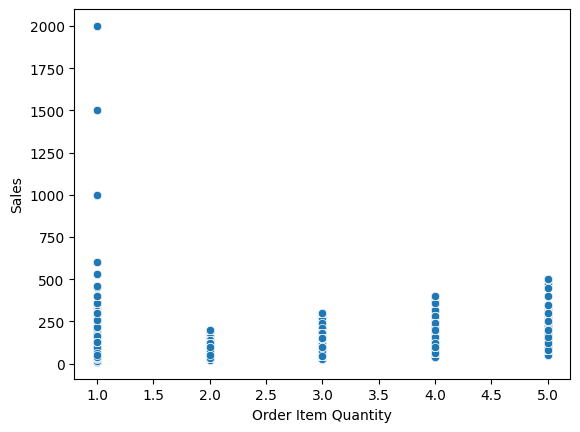

In [28]:
# Sales VS Quantity
sns.scatterplot(
    x='Order Item Quantity',
    y='Sales',
    data=data_supply
)

## Outlier Detection

<Axes: xlabel='Order Item Product Price'>

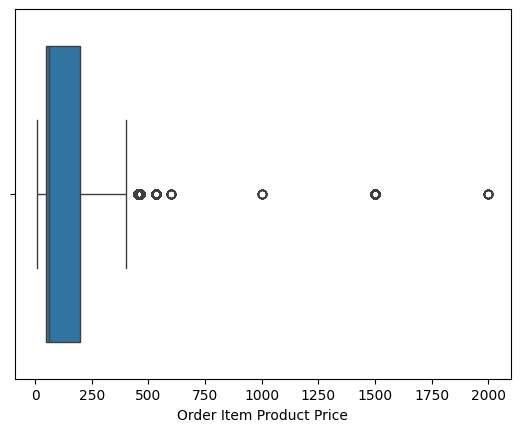

In [29]:
sns.boxplot(x=data_supply['Order Item Product Price'])

In [30]:
Q1 = data_supply['Order Item Product Price'].quantile(0.25)
Q3 = data_supply['Order Item Product Price'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = data_supply[
    (data_supply['Order Item Product Price'] < lower_bound) |
    (data_supply['Order Item Product Price'] > upper_bound)
]

outliers.head()

Q1: 50.0
Q3: 199.9900055
IQR: 149.9900055
Lower Bound: -174.98500825
Upper Bound: 424.97501375


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Shipping_Delay,Price_Ratio
146,DEBIT,4,2,120.830002,447.519989,Late delivery,1,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/18/2017 11:42,Second Class,2,1.0
148,DEBIT,6,2,212.639999,443.000000,Late delivery,1,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/22/2017 1:12,Second Class,4,1.0
150,DEBIT,6,2,135.830002,433.959992,Late delivery,1,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/19/2017 3:08,Second Class,4,1.0
152,DEBIT,5,2,595.349976,1417.500000,Late delivery,1,64,Computers,Caguas,...,1351,64,http://images.acmesports.sports/Dell+Laptop,Dell Laptop,1500.000000,0,11/3/2017 12:55,Second Class,3,1.0
153,DEBIT,2,2,21.360001,427.179993,Shipping on time,0,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/15/2017 8:44,Second Class,0,1.0


In [3]:
# ============================================================
# EDA: Shipping Mode vs Scheduled Days
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from scipy.stats import chi2_contingency

# ============================================================
# Load Data
# ============================================================

raw_path = "d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    raw_path,
    encoding="latin1",
    usecols=[
        "Shipping Mode",
        "Days for shipment (scheduled)",
        "Late_delivery_risk"
    ]
)

df_eda = df.dropna().copy()

df_eda["Days for shipment (scheduled)"] = (
    df_eda["Days for shipment (scheduled)"].astype(int)
)

df_eda.head()


,Days for shipment (scheduled),Late_delivery_risk,Shipping Mode
0,4,0,Standard Class
1,4,1,Standard Class
2,4,0,Standard Class
3,4,0,Standard Class
4,4,0,Standard Class


In [4]:
# ============================================================
# Basic Distribution
# ============================================================

print("Shape:", df_eda.shape)

print("\nShipping Mode Distribution:")
display(df_eda["Shipping Mode"].value_counts())

print("\nScheduled Days Distribution:")
display(df_eda["Days for shipment (scheduled)"].value_counts().sort_index())


Shape: (180519, 3)

Shipping Mode Distribution:


Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


Scheduled Days Distribution:


Days for shipment (scheduled)
0      9737
1     27814
2     35216
4    107752
Name: count, dtype: int64

In [5]:
# ============================================================
# Crosstab: Shipping Mode vs Scheduled Days
# ============================================================

cross_counts = pd.crosstab(
    df_eda["Shipping Mode"],
    df_eda["Days for shipment (scheduled)"]
)

cross_pct = pd.crosstab(
    df_eda["Shipping Mode"],
    df_eda["Days for shipment (scheduled)"],
    normalize="index"
) * 100

print("Crosstab Count:")
display(cross_counts)

print("Crosstab Percentage by Shipping Mode:")
display(cross_pct.round(2))


Crosstab Count:


Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0,27814,0,0
Same Day,9737,0,0,0
Second Class,0,0,35216,0
Standard Class,0,0,0,107752


Crosstab Percentage by Shipping Mode:


Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0.0,100.0,0.0,0.0
Same Day,100.0,0.0,0.0,0.0
Second Class,0.0,0.0,100.0,0.0
Standard Class,0.0,0.0,0.0,100.0


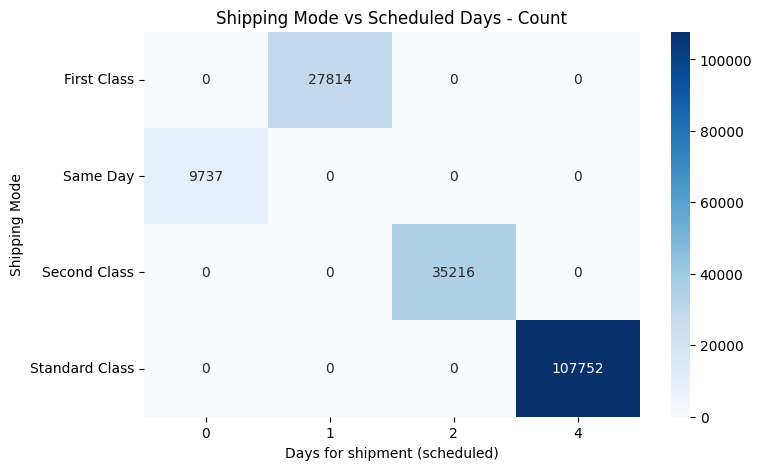

In [6]:
# ============================================================
# Heatmap Crosstab Count
# ============================================================

plt.figure(figsize=(8, 5))
sns.heatmap(
    cross_counts,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Shipping Mode vs Scheduled Days - Count")
plt.xlabel("Days for shipment (scheduled)")
plt.ylabel("Shipping Mode")
plt.show()


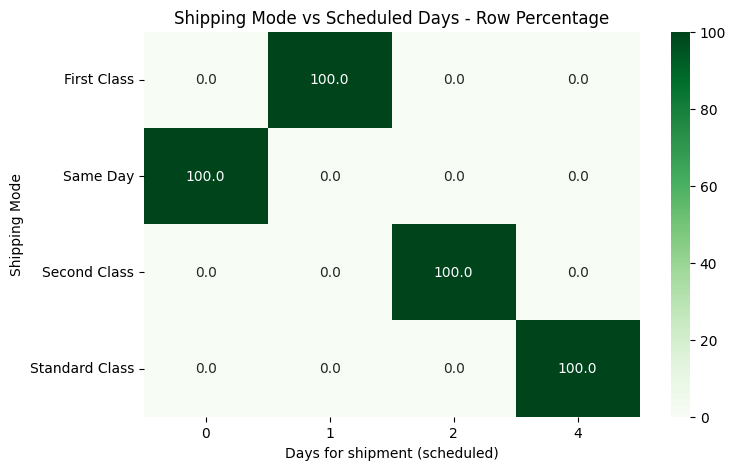

In [7]:
# ============================================================
# Heatmap Crosstab Percentage
# ============================================================

plt.figure(figsize=(8, 5))
sns.heatmap(
    cross_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)
plt.title("Shipping Mode vs Scheduled Days - Row Percentage")
plt.xlabel("Days for shipment (scheduled)")
plt.ylabel("Shipping Mode")
plt.show()


In [8]:
# ============================================================
# Cek Apakah Mapping-nya Hampir 1-to-1
# ============================================================

mode_to_days = (
    df_eda
    .groupby("Shipping Mode")["Days for shipment (scheduled)"]
    .agg(["nunique", "unique"])
)

days_to_mode = (
    df_eda
    .groupby("Days for shipment (scheduled)")["Shipping Mode"]
    .agg(["nunique", "unique"])
)

print("Unique scheduled days per Shipping Mode:")
display(mode_to_days)

print("Unique Shipping Mode per scheduled days:")
display(days_to_mode)


Unique scheduled days per Shipping Mode:


,nunique,unique
Shipping Mode,,
First Class,1,[1]
Same Day,1,[0]
Second Class,1,[2]
Standard Class,1,[4]


Unique Shipping Mode per scheduled days:


,nunique,unique
Days for shipment (scheduled),,
0,1,[Same Day]
1,1,[First Class]
2,1,[Second Class]
4,1,[Standard Class]


In [9]:
# ============================================================
# Chi-Square Test: Apakah Shipping Mode dan Scheduled Days Berhubungan?
# ============================================================

chi2, p_value, dof, expected = chi2_contingency(cross_counts)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Kesimpulan: Shipping Mode dan Scheduled Days memiliki hubungan yang signifikan.")
else:
    print("Kesimpulan: Tidak ada hubungan signifikan antara Shipping Mode dan Scheduled Days.")


Chi-square: 541557.0
p-value: 0.0
Degrees of freedom: 9
Kesimpulan: Shipping Mode dan Scheduled Days memiliki hubungan yang signifikan.


In [10]:
# ============================================================
# Mutual Information
# Nilai mendekati 1 berarti hubungan sangat kuat / hampir redundant
# ============================================================

mi = mutual_info_score(
    df_eda["Shipping Mode"],
    df_eda["Days for shipment (scheduled)"]
)

nmi = normalized_mutual_info_score(
    df_eda["Shipping Mode"],
    df_eda["Days for shipment (scheduled)"]
)

print("Mutual Information:", mi)
print("Normalized Mutual Information:", nmi)


Mutual Information: 1.072500502545584
Normalized Mutual Information: 1.0


,count,late_risk_rate
Shipping Mode,,
First Class,27814,0.953225
Second Class,35216,0.766328
Same Day,9737,0.457430
Standard Class,107752,0.380717


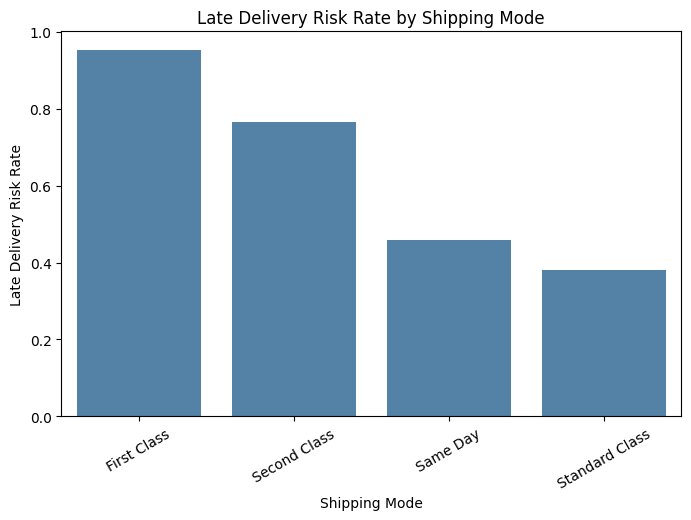

In [11]:
# ============================================================
# Late Delivery Risk Rate by Shipping Mode
# ============================================================

risk_by_mode = (
    df_eda
    .groupby("Shipping Mode")["Late_delivery_risk"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "late_risk_rate"})
    .sort_values("late_risk_rate", ascending=False)
)

display(risk_by_mode)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=risk_by_mode.reset_index(),
    x="Shipping Mode",
    y="late_risk_rate",
    color="steelblue"
)
plt.title("Late Delivery Risk Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Risk Rate")
plt.xticks(rotation=30)
plt.show()


,count,late_risk_rate
Days for shipment (scheduled),,
0,9737,0.457430
1,27814,0.953225
2,35216,0.766328
4,107752,0.380717


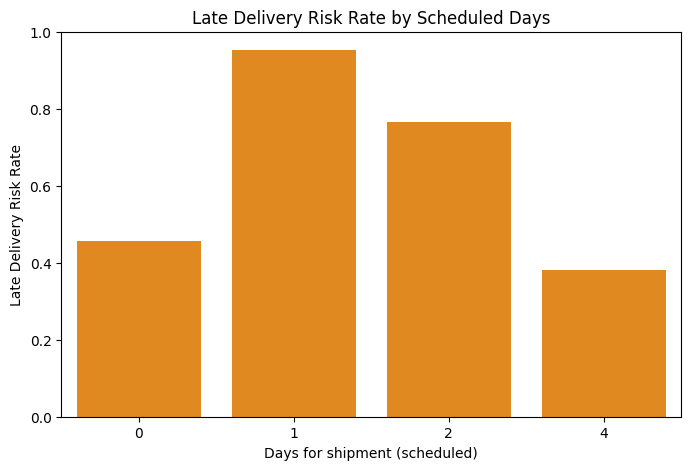

In [12]:
# ============================================================
# Late Delivery Risk Rate by Scheduled Days
# ============================================================

risk_by_days = (
    df_eda
    .groupby("Days for shipment (scheduled)")["Late_delivery_risk"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "late_risk_rate"})
    .sort_index()
)

display(risk_by_days)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=risk_by_days.reset_index(),
    x="Days for shipment (scheduled)",
    y="late_risk_rate",
    color="darkorange"
)
plt.title("Late Delivery Risk Rate by Scheduled Days")
plt.xlabel("Days for shipment (scheduled)")
plt.ylabel("Late Delivery Risk Rate")
plt.show()


In [13]:
# ============================================================
# Combined Risk: Shipping Mode x Scheduled Days
# ============================================================

risk_matrix = pd.pivot_table(
    df_eda,
    values="Late_delivery_risk",
    index="Shipping Mode",
    columns="Days for shipment (scheduled)",
    aggfunc="mean"
)

count_matrix = pd.pivot_table(
    df_eda,
    values="Late_delivery_risk",
    index="Shipping Mode",
    columns="Days for shipment (scheduled)",
    aggfunc="count"
)

print("Risk Matrix:")
display(risk_matrix.round(3))

print("Count Matrix:")
display(count_matrix)


Risk Matrix:


Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,NaN,0.953,NaN,NaN
Same Day,0.457,NaN,NaN,NaN
Second Class,NaN,NaN,0.766,NaN
Standard Class,NaN,NaN,NaN,0.381


Count Matrix:


Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,NaN,27814.0,NaN,NaN
Same Day,9737.0,NaN,NaN,NaN
Second Class,NaN,NaN,35216.0,NaN
Standard Class,NaN,NaN,NaN,107752.0


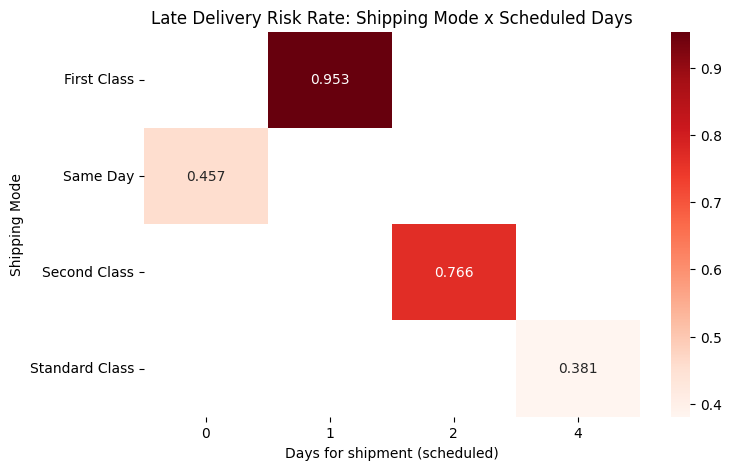

In [14]:
# ============================================================
# Heatmap Combined Risk
# ============================================================

plt.figure(figsize=(8, 5))
sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".3f",
    cmap="Reds"
)
plt.title("Late Delivery Risk Rate: Shipping Mode x Scheduled Days")
plt.xlabel("Days for shipment (scheduled)")
plt.ylabel("Shipping Mode")
plt.show()


In [15]:
# ============================================================
# Interpretasi Otomatis Sederhana
# ============================================================

print("=== Interpretasi Awal ===")

if nmi >= 0.90:
    print("Shipping Mode dan Scheduled Days sangat redundant.")
    print("Kemungkinan cukup pakai salah satu saja.")
elif nmi >= 0.70:
    print("Shipping Mode dan Scheduled Days punya hubungan kuat.")
    print("Boleh dipertimbangkan pilih salah satu atau biarkan model tree memilih.")
elif nmi >= 0.40:
    print("Shipping Mode dan Scheduled Days punya hubungan sedang.")
    print("Keduanya masih mungkin membawa informasi berbeda.")
else:
    print("Hubungan Shipping Mode dan Scheduled Days relatif lemah.")
    print("Keduanya layak dipertahankan sebagai fitur berbeda.")

print("\nRisk by Shipping Mode:")
display(risk_by_mode)

print("\nRisk by Scheduled Days:")
display(risk_by_days)


=== Interpretasi Awal ===
Shipping Mode dan Scheduled Days sangat redundant.
Kemungkinan cukup pakai salah satu saja.

Risk by Shipping Mode:


,count,late_risk_rate
Shipping Mode,,
First Class,27814,0.953225
Second Class,35216,0.766328
Same Day,9737,0.457430
Standard Class,107752,0.380717



Risk by Scheduled Days:


,count,late_risk_rate
Days for shipment (scheduled),,
0,9737,0.457430
1,27814,0.953225
2,35216,0.766328
4,107752,0.380717
